### Problem statement
> Analyse the impact of AI on jobs as per the data given and develop a dashboard to present your findings

###1. EDA Analysis

In [27]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import numpy as numpy

In [28]:
# Load the dataset

file_path = r"C:\Users\Admin\Desktop\Advanced_Visualizations\Datasets\AI_Impact_on_Jobs_2030.csv"
df = pd.read_csv(file_path)
df.head()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


### Eyeballing

finding out the shape of the data set eg how many rows and columns are there, specific column names, data types

In [29]:
df.shape # How many rows and columns are in the dataset

(3000, 20)

In [30]:
df.columns

Index(['Employee_ID', 'Job_Title', 'Industry', 'Country', 'Education_Level',
       'Years_Experience', 'AI_Replacement_Risk', 'Future_Demand_Score',
       'Remote_Work_Possibility', 'Average_Salary_USD', 'Required_Skills',
       'Automation_Level', 'Job_Growth_2030', 'Work_Hours_Per_Week',
       'Company_Size', 'AI_Tool_Usage', 'Performance_Score',
       'Upskilling_Needed', 'Job_Satisfaction', 'Hiring_Trend_2026'],
      dtype='str')

In [31]:
df.dtypes

Employee_ID                    str
Job_Title                      str
Industry                       str
Country                        str
Education_Level                str
Years_Experience             int64
AI_Replacement_Risk        float64
Future_Demand_Score        float64
Remote_Work_Possibility        str
Average_Salary_USD           int64
Required_Skills                str
Automation_Level               str
Job_Growth_2030              int64
Work_Hours_Per_Week          int64
Company_Size                   str
AI_Tool_Usage                  str
Performance_Score          float64
Upskilling_Needed              str
Job_Satisfaction           float64
Hiring_Trend_2026              str
dtype: object

In [32]:
df['Industry'].unique()

<StringArray>
[    'Healthcare',         'Retail',      'Education',     'Government',
         'Energy',          'Media',     'Technology',  'Manufacturing',
        'Finance', 'Transportation']
Length: 10, dtype: str

### 2.Analysis

1. Univariate Analysis

In [33]:
ind_df = df['Industry'].value_counts().sort_values(ascending=False).reset_index() # Sort the industries by the number of job losses
ind_df.columns = ['Type of Industry', 'Total'] # Rename the columns for better understanding
ind_df

,Type of Industry,Total
0,Energy,335
1,Government,323
2,Finance,310
3,Manufacturing,303
4,Education,300
5,Transportation,293
6,Technology,291
7,Media,287
8,Retail,285
9,Healthcare,273


In [34]:
# I represented this as a pie chart to show the proportion of job losses in each industry. The pie chart provides a clear visual representation of how different industries are affected by AI and automation, allowing for easy comparison of the impact across sectors.
fig =px.pie(
    data_frame=ind_df,
    values='Total',
    labels='Type of Industry',
    title='Distribution of industries affected by AI and automation in 2030',
    width=800,
)
fig.show()

In [35]:
#What is the avg salary in each industry?
ave_salary_df=df.groupby('Industry')['Average_Salary_USD'].mean().sort_values(ascending=False).reset_index()
ave_salary_df.columns = ['Industry', 'Average Salary']
ave_salary_df

,Industry,Average Salary
0,Finance,132016.529032
1,Media,129684.560976
2,Transportation,129411.112628
3,Manufacturing,128614.168317
4,Technology,127689.281787
5,Energy,127261.164179
6,Healthcare,125682.307692
7,Education,124409.966667
8,Retail,121075.284211
9,Government,120626.349845


In [36]:
px.bar(
    data_frame=ave_salary_df,
    y='Industry',
    x='Average Salary',
    height=600,
    width=800,
    title='Average Salary by Industry in 2030',
    text_auto=True,
    template='plotly_dark'
)

In [37]:
df[df['Job_Title'] == 'Software Developer'].groupby('Industry')['Average_Salary_USD'].mean().sort_values(ascending=False).reset_index()

,Industry,Average_Salary_USD
0,Energy,150591.789474
1,Technology,138551.200000
2,Retail,137106.416667
3,Manufacturing,132260.285714
4,Media,126673.095238
5,Healthcare,120644.000000
6,Transportation,119735.066667
7,Finance,116771.062500
8,Education,107305.954545
9,Government,93051.000000


<Axes: title={'center': 'Distribution of Years of Experience'}, ylabel='Frequency'>

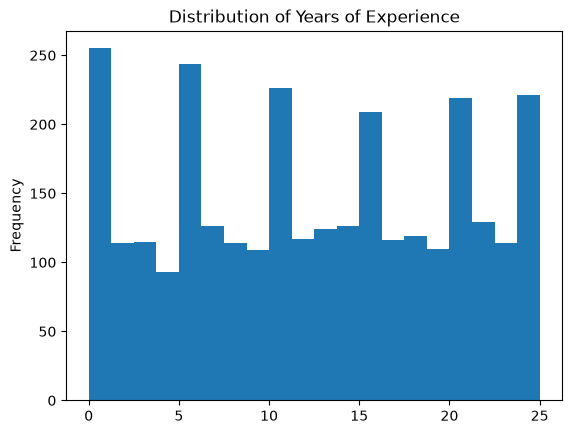

In [38]:
df['Years_Experience'].plot(kind='hist', bins=20, title='Distribution of Years of Experience')

In [39]:
df['AI_Tool_Usage'].value_counts()

AI_Tool_Usage
Low         1033
High        1014
Moderate     953
Name: count, dtype: int64

In [40]:
#Which industry has the highest AI Usage?
df.groupby(['Industry', 'AI_Tool_Usage']).agg(
    count = ('AI_Tool_Usage', 'count')
).unstack().reset_index()

Industry count              
AI_Tool_Usage                  High  Low Moderate
0                   Education   104  107       89
1                      Energy   120  101      114
2                     Finance   103  109       98
3                  Government   110  111      102
4                  Healthcare    87   97       89
5               Manufacturing    98  109       96
6                       Media    92  100       95
7                      Retail    87  105       93
8                  Technology    93  109       89
9              Transportation   120   85       88

In [41]:
df.head().T # Transpose the dataframe to view the columns as rows for better readability

,0,1,2,3,4
Employee_ID,AIJ-100000,AIJ-100001,AIJ-100002,AIJ-100003,AIJ-100004
Job_Title,Data Engineer,Healthcare Analyst,HR Specialist,Cybersecurity Analyst,Healthcare Analyst
Industry,Healthcare,Retail,Education,Government,Education
Country,Japan,UK,Canada,UK,UAE
Education_Level,PhD,Bachelor,High School,Bachelor,PhD
Years_Experience,1,24,21,5,20
AI_Replacement_Risk,0.25,0.73,0.8,0.29,0.11
Future_Demand_Score,0.78,0.33,0.69,0.94,0.92
Remote_Work_Possibility,Yes,No,Yes,No,No
Average_Salary_USD,207392,140785,124800,199878,178682
